In [1]:
import numpy as np
# import cupy as cp
# import numba as nb
import datetime as dt
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import h5py
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

2024-06-16 05:57:36.453977: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-16 05:57:36.454073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-16 05:57:36.583464: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
len(tf.config.list_physical_devices('GPU'))

1

In [3]:
tf.test.is_gpu_available

<function tensorflow.python.framework.test_util.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)>

In [4]:
gpu_available = tf.test.is_gpu_available()
is_cuda_gpu_available = tf.test.is_gpu_available(cuda_only=True)
is_cuda_gpu_min_3 = tf.test.is_gpu_available(True, (3,0))
tf.test.is_gpu_available

<function tensorflow.python.framework.test_util.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)>

In [5]:
tf.test.is_gpu_available

<function tensorflow.python.framework.test_util.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)>

In [6]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [7]:
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 16, 10
# RANDOM_SEED = 42
# cp.random.seed(RANDOM_SEED)
# tf.random.set_seed(RANDOM_SEED)

In [8]:
df = pd.read_csv('/kaggle/input/dataset/Impute_misvalues_hungyen.csv')
df.head()

,Date,Hour,Waterlevel
0,01/01/2008,0,47.0
1,01/01/2008,1,43.0
2,01/01/2008,2,40.0
3,01/01/2008,3,37.0
4,01/01/2008,4,34.0


In [9]:
df['Hour'] = df['Hour'].replace('#NUM!', 0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64061 entries, 0 to 64060
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        64061 non-null  object 
 1   Hour        64061 non-null  object 
 2   Waterlevel  64061 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.5+ MB


In [11]:
df.describe()

,Waterlevel
count,64061.000000
mean,138.135113
std,97.020489
min,-26.000000
25%,75.000000
50%,116.000000
75%,171.000000
max,651.000000


In [12]:
df.isnull().sum()

Date          0
Hour          0
Waterlevel    0
dtype: int64

In [13]:
df['Hour'] = pd.to_datetime(df['Hour'], format='%H', errors='coerce').dt.time
df.head()

,Date,Hour,Waterlevel
0,01/01/2008,00:00:00,47.0
1,01/01/2008,01:00:00,43.0
2,01/01/2008,02:00:00,40.0
3,01/01/2008,03:00:00,37.0
4,01/01/2008,04:00:00,34.0


In [14]:
df['Hour'] = df['Hour'].astype(str)


df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Hour']
        )
df = df.set_index('DateTime')
df.drop(['Date', 'Hour'], 
        axis = 1, inplace = True)

df.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,47.0
2008-01-01 01:00:00,43.0
2008-01-01 02:00:00,40.0
2008-01-01 03:00:00,37.0
2008-01-01 04:00:00,34.0


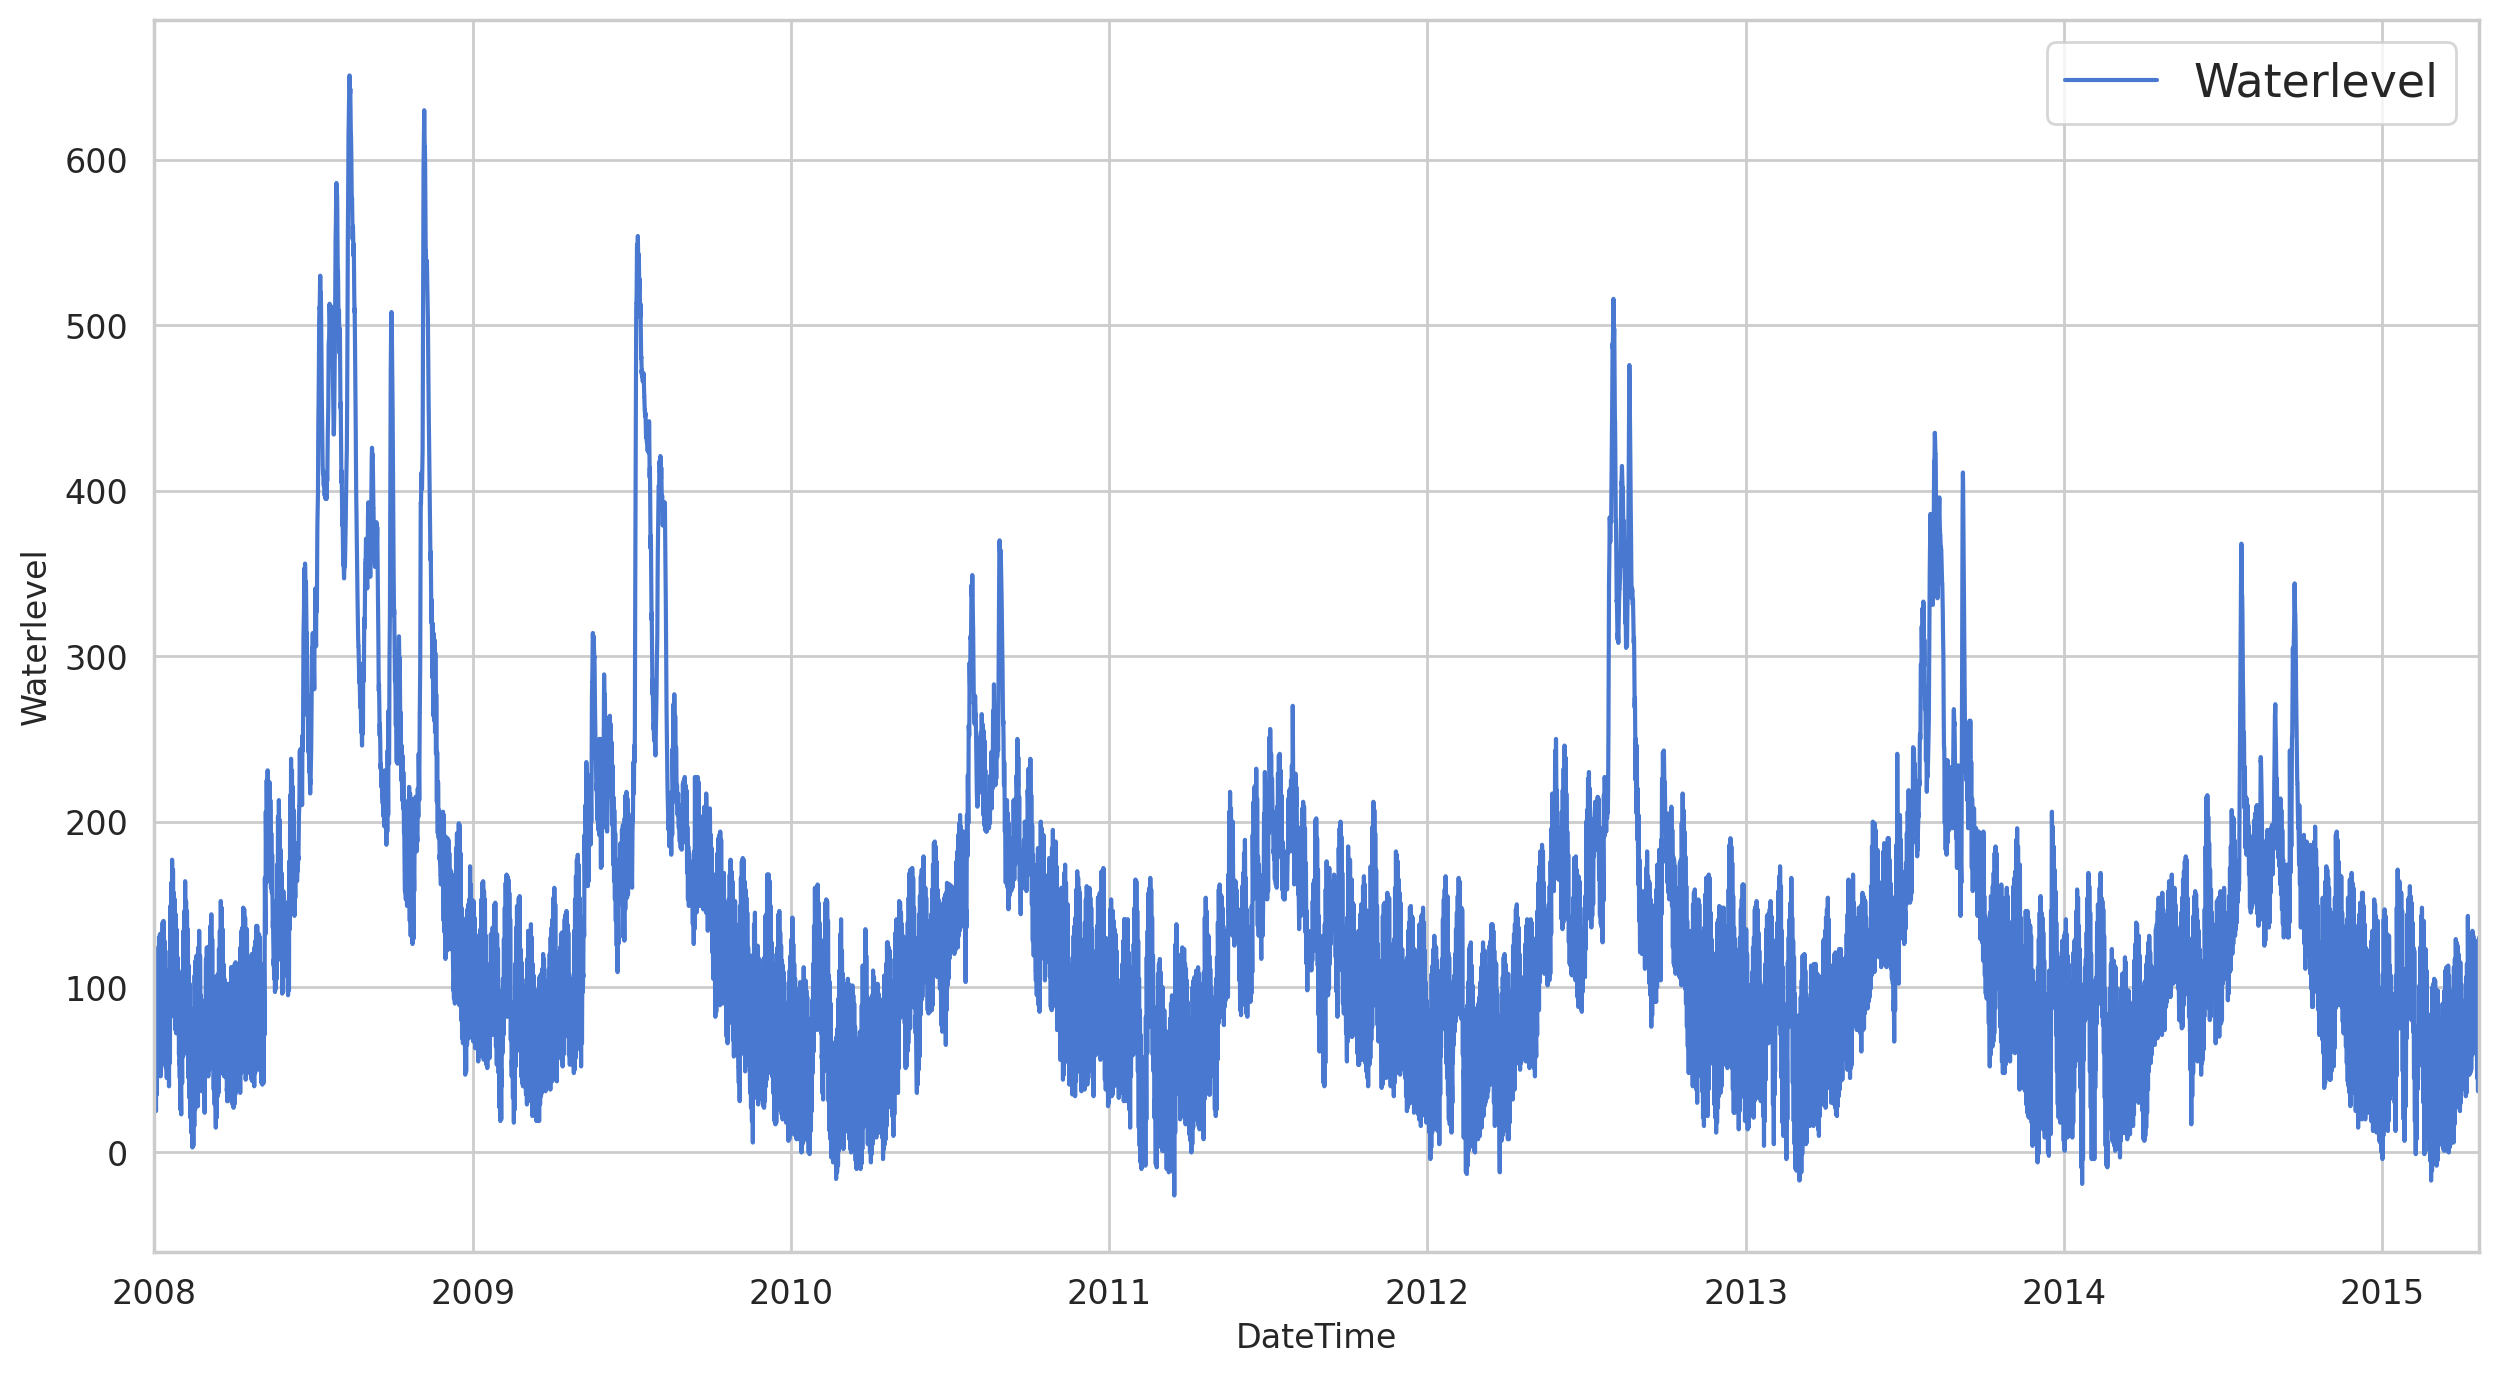

In [15]:
df.plot(y='Waterlevel', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)
plt.show()

In [16]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.85)
train, val, test = df[:train_size].iloc[:, [-1]], df[train_size:val_size].iloc[:, [-1]] , df[val_size:].iloc[:, [-1]]

train, val, test

(                     Waterlevel
 DateTime                       
 2008-01-01 00:00:00        47.0
 2008-01-01 01:00:00        43.0
 2008-01-01 02:00:00        40.0
 2008-01-01 03:00:00        37.0
 2008-01-01 04:00:00        34.0
 ...                         ...
 2013-02-11 05:00:00        86.0
 2013-02-11 06:00:00       100.0
 2013-02-11 07:00:00       115.0
 2013-02-11 08:00:00       128.0
 2013-02-11 09:00:00       134.0
 
 [44842 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2013-02-11 10:00:00       133.0
 2013-02-11 11:00:00       127.0
 2013-02-11 12:00:00       122.0
 2013-02-11 13:00:00       115.0
 2013-02-11 14:00:00       107.0
 ...                         ...
 2014-03-18 14:00:00        46.0
 2014-03-18 15:00:00        54.0
 2014-03-18 16:00:00        61.0
 2014-03-18 17:00:00        65.0
 2014-03-18 18:00:00        65.0
 
 [9609 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2014-03-18 19:00:0

In [17]:
train.shape, val.shape, test.shape

((44842, 1), (9609, 1), (9610, 1))

Text(0, 0.5, 'Waterlevel')

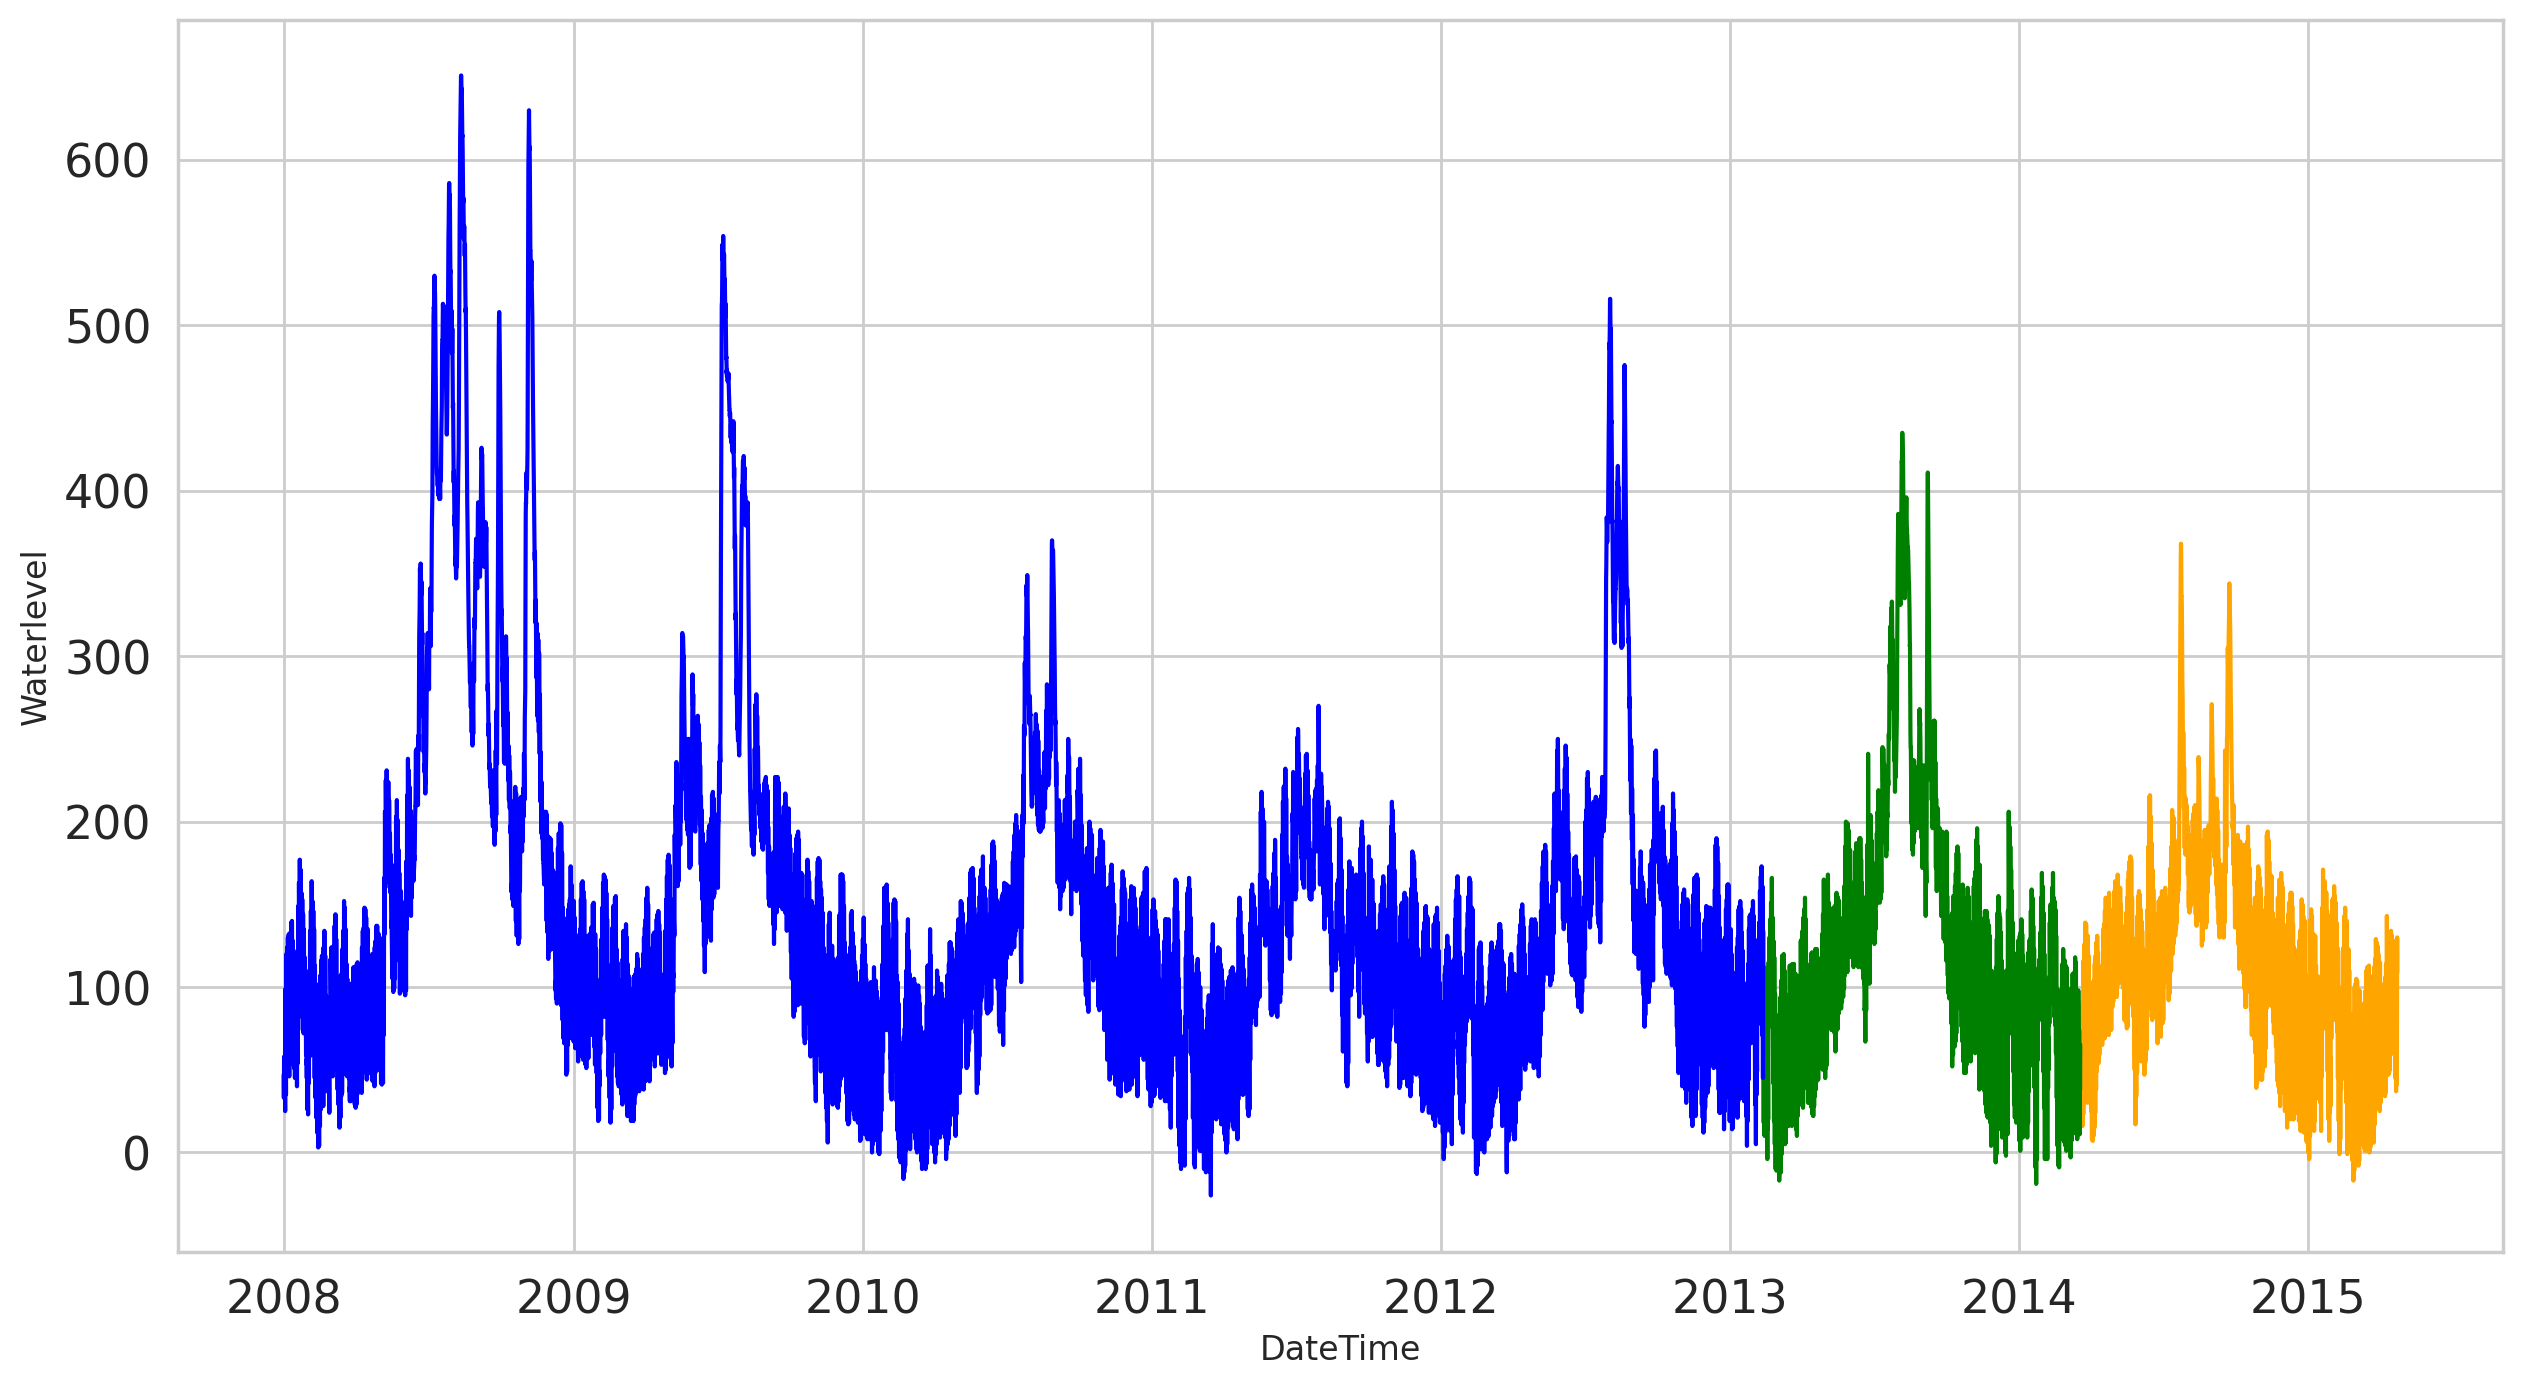

In [18]:
plt.figure(figsize = (15,8))
plt.plot(test.index, test['Waterlevel'], label = "test", color = 'orange')
plt.plot(val.index, val['Waterlevel'], label = "val", color = 'green')
plt.plot(train.index, train['Waterlevel'], label = "train" , color = 'blue')
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)

In [19]:
scaler = MinMaxScaler()
train['Waterlevel'] = scaler.fit_transform(train)
val['Waterlevel'] = scaler.transform(val)
test['Waterlevel'] = scaler.transform(test)

In [20]:
train_data = train.values
val_data = val.values
test_data = test.values

In [21]:
timesteps = 164

In [22]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] 
                               for i in range(0,len(train_data)-timesteps+1)])[:,:,0]
val_data_timesteps=np.array([[j for j in val_data[i:i+timesteps]] 
                             for i in range(0,len(val_data)-timesteps+1)])[:,:,0]
test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] 
                              for i in range(0,len(test_data)-timesteps+1)])[:,:,0]


In [23]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_val, y_val = val_data_timesteps[:,:timesteps-1],val_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

x_train, y_train

(array([[0.10782866, 0.10192024, 0.09748892, ..., 0.17282127, 0.16395864,
         0.15509601],
        [0.10192024, 0.09748892, 0.09305761, ..., 0.16395864, 0.15509601,
         0.14623338],
        [0.09748892, 0.09305761, 0.08862629, ..., 0.15509601, 0.14623338,
         0.13737075],
        ...,
        [0.1816839 , 0.17725258, 0.17282127, ..., 0.14327917, 0.16543575,
         0.18611521],
        [0.17725258, 0.17282127, 0.16838996, ..., 0.16543575, 0.18611521,
         0.20827179],
        [0.17282127, 0.16838996, 0.16395864, ..., 0.18611521, 0.20827179,
         0.22747415]]),
 array([[0.14623338],
        [0.13737075],
        [0.12998523],
        ...,
        [0.20827179],
        [0.22747415],
        [0.23633678]]))

In [24]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    squared_error = np.mean((y_true - y_pred)**2)

    r, _ = pearsonr(y_true, y_pred)
    
    T = len(y_true)
    max_x = max(y_true)
    min_x = min(y_true)
    
    sim_sum = 0
    for i in range(T):
        sim_sum += 1 / (1 + abs(y_pred[i] - y_true[i]) / (max_x - min_x))
    sim = sim_sum / T
    
    sd_y = np.std(y_pred)
    sd_x = np.std(y_test)
    fsd = 2 * np.abs(sd_y - sd_x) / (sd_y + sd_x)
    
    nse = 1 - (np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MSE' : squared_error,
        'R': r,
        'SIM': sim,
        'FSD': fsd,
        'NSE': nse
    }

### LSTM

In [25]:
# model = keras.Sequential()
# model.add(keras.layers.LSTM(
#   units=128,
#   input_shape=(x_train.shape[1], 1)
# ))
# model.add(keras.layers.Dense(units=1))
# model.compile(
#   loss='mean_squared_error',
#   optimizer=keras.optimizers.Adam()
# )

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [27]:
x_train.shape[1]

163

In [28]:
# model = keras.Sequential()
# model.add(keras.layers.LSTM(
#   units=128,
#   input_shape=(x_train.shape[1], 1)
# ))
# model.add(Dense(64, 'relu'))
# model.add(Dropout(0.15))
# # model.add(Dense(32, 'relu'))
# # model.add(Dropout(0.15))
# # model.add(Dense(16, 'relu'))
# # model.add(Dropout(0.15))
# # model.add(Dense(8, 'relu'))
# # model.add(Dropout(0.15))
# model.add(Dense(1))
# model.compile(
#   loss=MeanSquaredError(), 
#   optimizer=Adam(learning_rate=0.0001), 
#   metrics=[RootMeanSquaredError()]
# )

In [29]:

# model = keras.Sequential()

#   # First LSTM layer with return_sequences=True
# model.add(keras.layers.LSTM(units=lstm_units, return_sequences=True,
#                               input_shape=x_train_shape))

#  # Stack additional LSTM layers with return_sequences=True
# for _ in range(1, n_lstm_layers):
#     model.add(keras.layers.LSTM(units=lstm_units, return_sequences=True))

#   # Final LSTM layer with return_sequences=False
# model.add(keras.layers.LSTM(units=lstm_units))

#   # Dense layer with dropout for regularization
# model.add(keras.layers.Dense(units=final_dense_units, activation=final_dense_activation))
# model.add(keras.layers.Dropout(dropout_rate))

#   # Output layer for regression (adjust units and activation as needed)
# model.add(keras.layers.Dense(1))  # For regression

#   # Compile the model
# model.compile(loss=tf.keras.losses.MeanSquaredError(),
#                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
#                 metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [30]:
# model = keras.Sequential()
# model.add(keras.layers.LSTM(
#   units=128,
#   input_shape=(x_train.shape[1], 1)
# ))
# model.add(Dense(100, 'relu'))
# # model.add(Dropout(0.5))
# # model.add(Dense(32, 'relu'))
# # model.add(Dropout(0.5))
# # model.add(Dense(16, 'relu'))
# model.add(Dropout(0.15))
# # model.add(Dense(8, 'relu'))
# # model.add(Dropout(0.15))
# model.add(Dense(1))
# model.compile(
#   loss=MeanSquaredError(), 
#   optimizer=Adam(learning_rate=0.0001), 
#   metrics=[RootMeanSquaredError()]
# )

In [31]:
# model = keras.Sequential()

# # First LSTM layer with 128 units
# model.add(keras.layers.LSTM(units=512, return_sequences=True, 
#                             input_shape=(x_train.shape[1], 1)))
# model.add(Dropout(0.2))
# model.add(keras.layers.LSTM(units=128, return_sequences=True))
# model.add(Dropout(0.2))
# model.add(keras.layers.LSTM(units=64, return_sequences=True))
# model.add(Dropout(0.2))
# model.add(keras.layers.LSTM(units=32))
# model.add(Flatten())
# model.add(Dense(16, 'relu'))
# model.add(Dropout(0.2))
# model.add(Dense(1))

# model.compile(
#   loss=MeanSquaredError(),
#   optimizer=Adam(learning_rate=0.0001),
#   metrics=[RootMeanSquaredError()]
# )


In [32]:
model = keras.Sequential()

model.add(keras.layers.LSTM(units=512, activation = 'tanh',
                            return_sequences=True, 
                            input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.1))
model.add(keras.layers.LSTM(units=256,activation = 'tanh',
                            return_sequences=True))
model.add(Dropout(0.1))
model.add(keras.layers.LSTM(units=64,activation = 'tanh',
                            return_sequences=True))
model.add(Dropout(0.1))
# model.add(keras.layers.LSTM(units=64,activation = 'tanh',
#                             return_sequences=True))
# model.add(Dropout(0.1))
model.add(keras.layers.LSTM(units=32))
model.add(Flatten())
model.add(Dense(32, 'relu'))
model.add(Dropout(0.1))
model.add(Dense((1), 'linear'))

model.compile(
  loss=MeanSquaredError(),
  optimizer=Adam(learning_rate=0.0001),
  metrics=[RootMeanSquaredError()]
)


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# cp1 = ModelCheckpoint('model/', save_best_only=True)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 163, 512)       │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 163, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 163, 256)       │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 163, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 163, 64)        │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 163, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,935,809 (7.38 MB)

 Trainable params: 1,935,809 (7.38 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.debugging.set_log_device_placement(True)

Num GPUs Available:  1


In [36]:
tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(True)

In [37]:
tf.device('/device:GPU:0')

In [38]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [39]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [40]:
tf.config.set_visible_devices

<function tensorflow.python.framework.config.set_visible_devices(devices, device_type=None)>

In [41]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    # callbacks=[cp1],
    epochs=50,
    batch_size=32,                       
    verbose=1,
    shuffle=False
)

Epoch 1/50
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - loss: 0.0069 - root_mean_squared_error: 0.0822 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0512
Epoch 2/50
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - loss: 0.0047 - root_mean_squared_error: 0.0668 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0415
Epoch 3/50
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - loss: 0.0028 - root_mean_squared_error: 0.0518 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0348
Epoch 4/50
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - loss: 0.0019 - root_mean_squared_error: 0.0431 - val_loss: 7.6582e-04 - val_root_mean_squared_error: 0.0277
Epoch 5/50
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - loss: 0.0018 - root_mean_squared_error: 0.0415 - val_loss: 5.3174e-04 - val_root_mean_squared_error: 0.0231
Epoch 6/50
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - loss: 0.0014 - root_mean_squared_error: 0.0370 - val_loss: 5.1886e-04 - val_root_mean_squared_error: 0.0228
Epoch 7/50
1397/

In [42]:
# from tensorflow.keras.models import load_model
# model = load_model('model/')

In [43]:
model.save('Model_1.h5')

In [44]:
model = keras.models.load_model('Model_1.h5')

In [45]:
# current_window = x_val[-1, : ].tolist()
# y_pred = model.predict([current_window])
# y_pred 

In [46]:
# hours = 120
# pred = []
# # def forecast(model, hours):
# #     current_window = x_val[-1,:].tolist()
# #     for i in range(hours):
# #         y_pred = model.predict([current_window])[0]
# #         pred.append(float(y_pred[0]))
# #         current_window.pop(0)
# #         current_window.append(float(y_pred[0]))
    
# #     pred_array = np.array(pred).reshape(-1,1)
# #     return(pred_array)



# # y_fc = forecast(model, hours)


# # def forecast(model, hours):
# #     pred = []
# #     current_window = x_val[-1, :].tolist()
# #     for i in range(hours):
# #         y_pred = model.predict(np.array([current_window]))[0]
# #         pred.append(float(y_pred[0]))
# #         current_window.pop(0)
# #         current_window.append(pred[-1])
# #     pred_array = np.array(pred).reshape(-1, 1)
# #     return pred_array

# # y_fc = forecast(model, hours)

# # def forecast(model, hours):
# #     pred = []
# #     current_window = x_val[-1,:].tolist()
# #     for i in range(hours):
# #         y_pred = model.predict([current_window])[0]
# #         pred.append(float(y_pred[0]))
# #         current_window.pop(0)
# #         current_window.append(pred[-1])
# #     pred_array = np.array(pred).reshape(-1,1)
# #     return pred_array

# # y_fc = forecast(model, hours)

# # def forecast(model, hours):
# #     pred = []
# #     current_window = x_val[-1,:].tolist()
# #     for i in range(hours):
# #         # Chuyển đổi current_window thành numpy array
# #         y_pred = model.predict(np.array([current_window]))[0]
# #         pred.append(float(y_pred[0]))
# #         current_window.pop(0)
# #         current_window.append(pred[-1])
# #     pred_array = np.array(pred).reshape(-1, 1)
# #     return pred_array

# # y_fc = forecast(model, hours)

# def forecast(model, hours):
#     pred = []
#     current_window = x_val[-1,:].tolist()
#     for i in range(hours):
#         # Chuyển current_window thành numpy array khi gọi predict
#         y_pred = model.predict(np.asarray([current_window]))[0]
#         pred.append(float(y_pred[0]))
#         current_window.pop(0)
#         current_window.append(pred[-1])
#     pred_array = np.array(pred).reshape(-1, 1)
#     return pred_array

# y_fc = forecast(model, hours)

# # def forecast(model, hours):
# #     pred = []
# #     current_window = x_val[-1,:]
# #     for i in range(hours):
# #         y_pred = model.predict(np.asarray([current_window]))[0]
# #         pred.append(float(y_pred[0]))
# #         current_window.pop(0)
# #         current_window.append(pred[-1])
# #     pred_array = np.array(pred).reshape(-1, 1)
# #     return pred_array

# # y_fc = forecast(model, hours)

In [47]:
# time = int(input("Enter the first time you want to forecast:"))
time = 77
hours = 120
pred = []

def forecast(model, hours, time):
    pred = []
    # current_window = x_val[-1,:].tolist()
    current_window = x_test[time,:].tolist()
    for i in range(hours):
        # Chuyển current_window thành numpy array khi gọi predict
        y_pred = model.predict(np.asarray([current_window]))[0]
        pred.append(float(y_pred[0]))
        current_window.pop(0)
        current_window.append(pred[-1])
    pred_array = np.array(pred).reshape(-1, 1)
    return pred_array

y_fc = forecast(model, hours, time)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━

In [48]:
y_pred = model.predict(x_test[time:])

293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [49]:
# hours = 120
# pred = []

# def forecast(model, x_train, hours):
#     current_window = np.array(x_train[-1, :]).reshape(1, -1)  # Convert to numpy array and reshape
#     for i in range(hours):
#         y_pred = model.predict(current_window)[0]
#         pred.append(float(y_pred))
#         current_window = np.roll(current_window, -1)  # Shift elements by 1
#         current_window[0, -1] = float(y_pred)  # Update the last element with the prediction
    
#     pred_array = np.array(pred).reshape(-1, 1)
#     return pred_array

# y_fc = forecast(model, x_train, hours)

In [50]:
# y_pred = model.predict(x_test)

In [51]:
y_test_original = scaler.inverse_transform(y_test)
y_pred_original = scaler.inverse_transform(y_pred)
y_fc_original = scaler.inverse_transform(y_fc)

In [52]:
# time_forecast = [3,  6, 12, 24, 36, 72, 120]
# for hours in time_forecast:
#     plt.figure(figsize=(20, 6))
    
#     plt.plot(y_test_original[:hours].flatten(), label='Actual', color='blue', marker='o')
#     plt.plot(y_pred_original[:hours], label='Predicted', color='red', marker='x')
#     plt.plot(y_fc_original[:hours].flatten(), label='Forecast', color='green', marker='x')
#     plt.title('Comparison of Actual and Predicted Values')
#     plt.xlabel('Hours')
#     plt.ylabel('Waterlevel')
#     plt.legend()

#     plt.show()

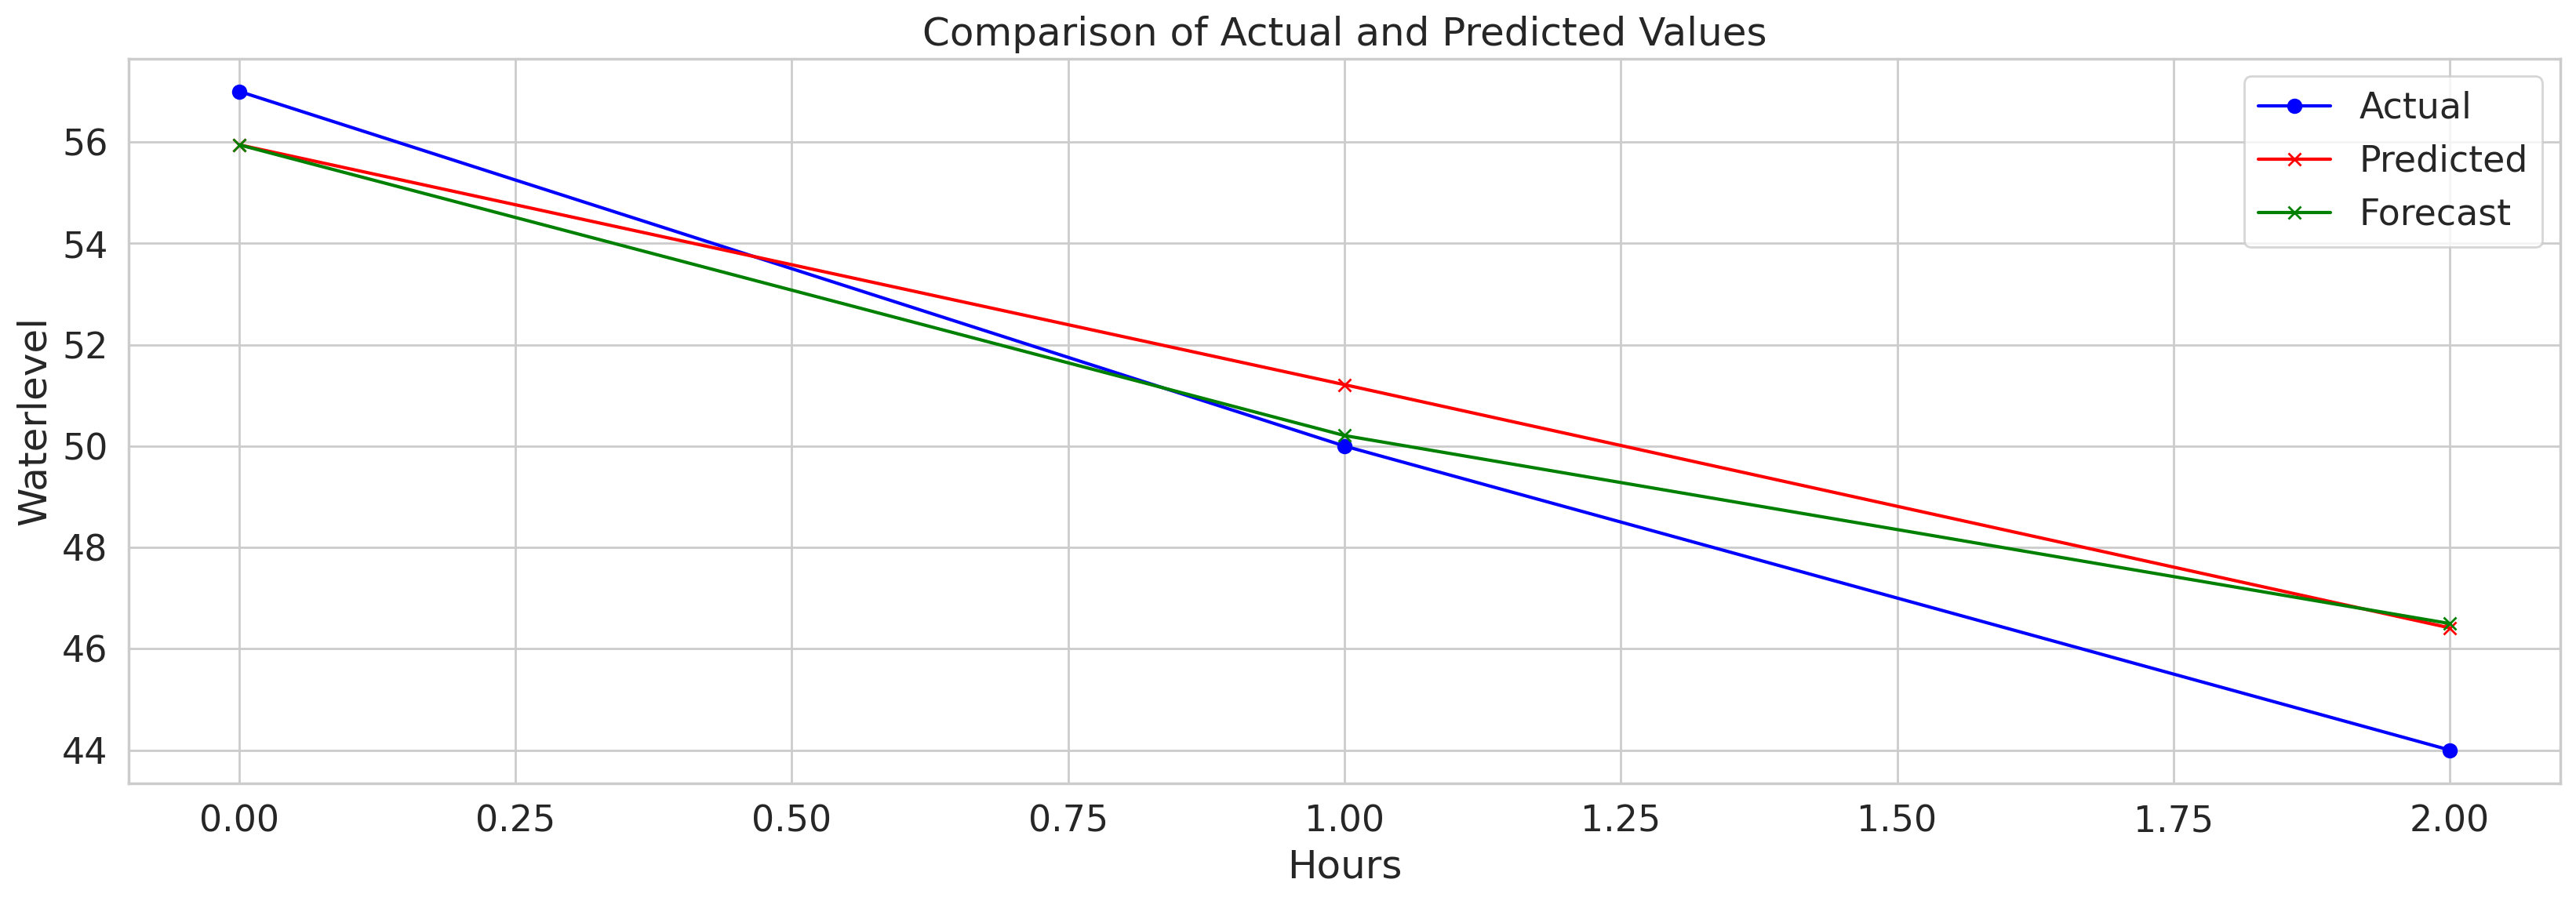

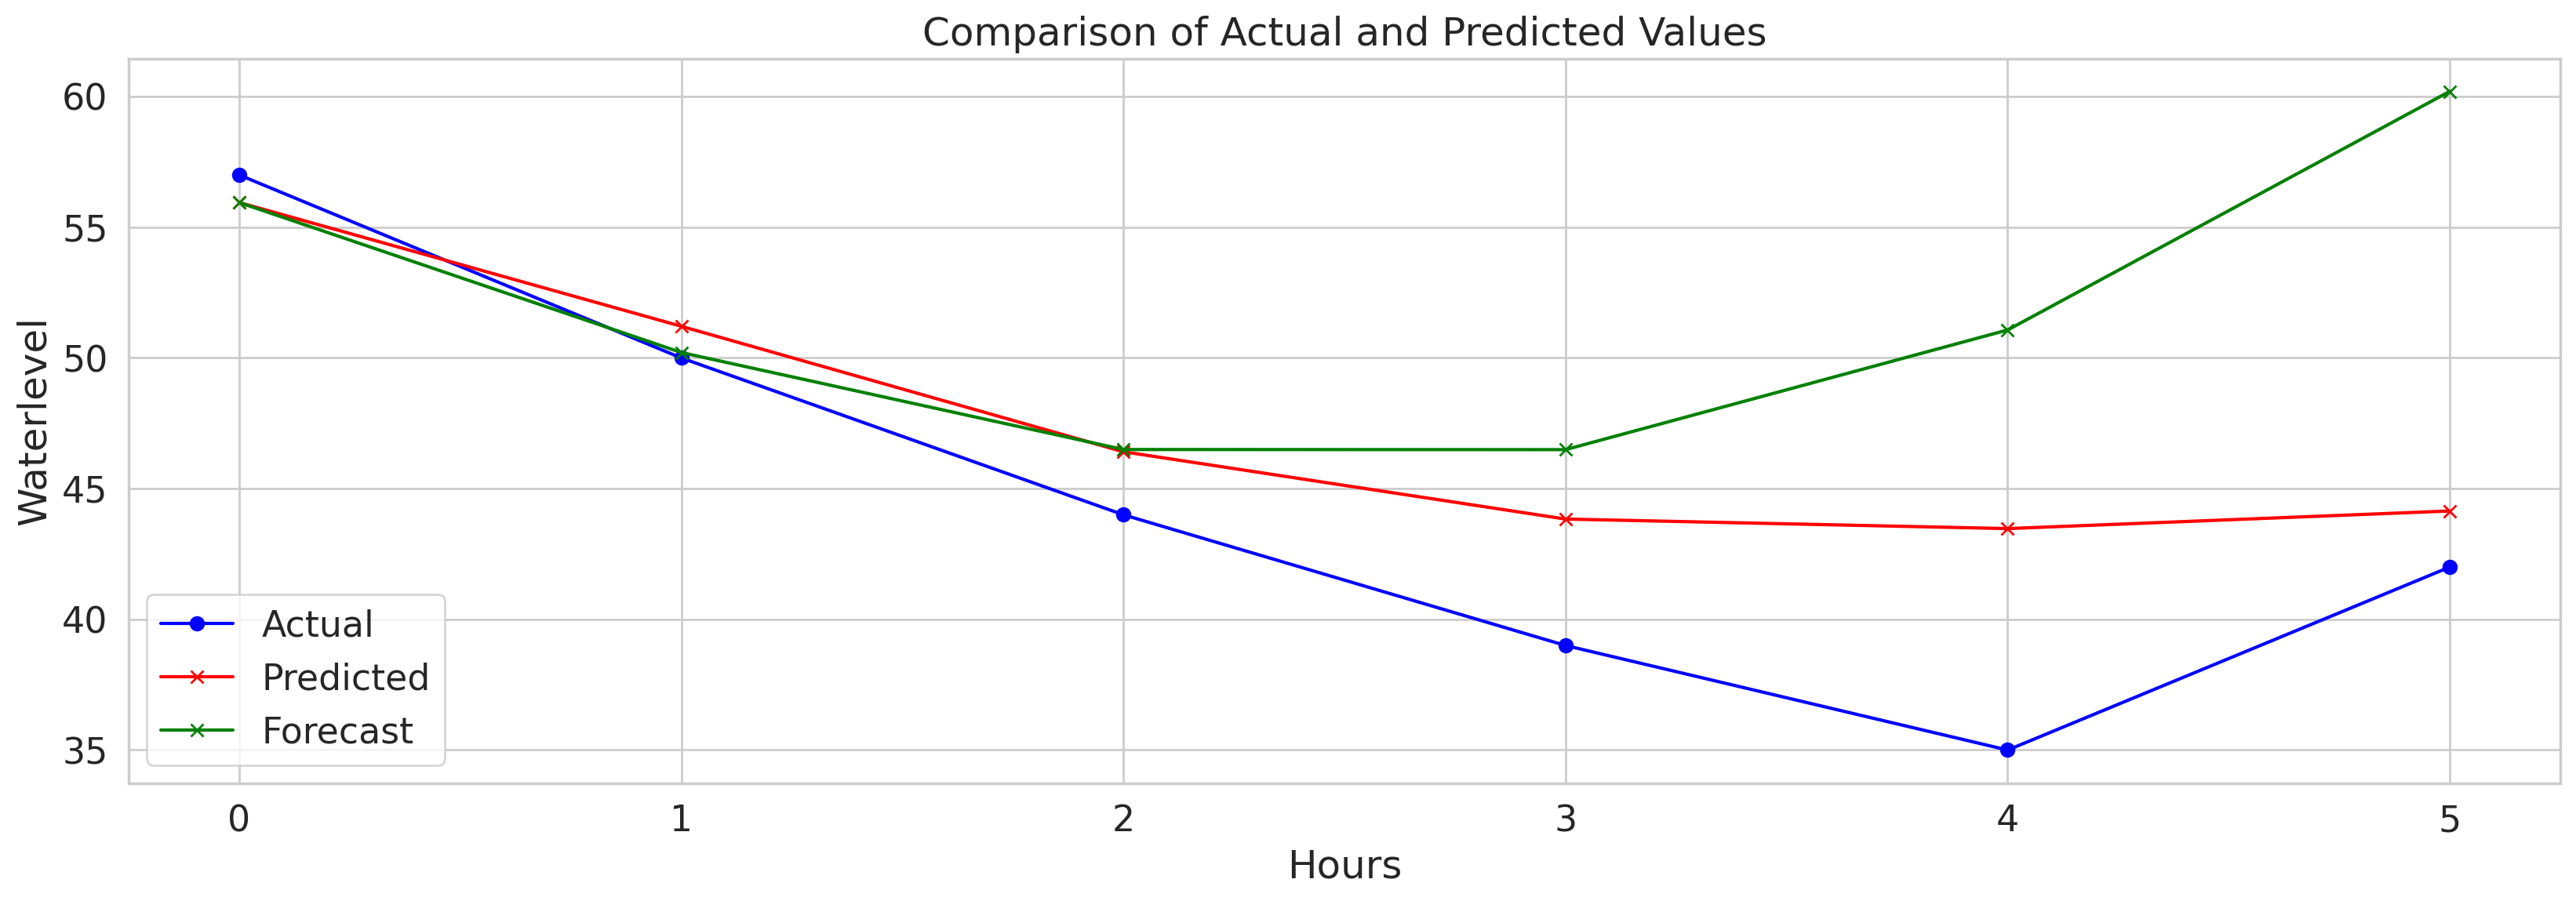

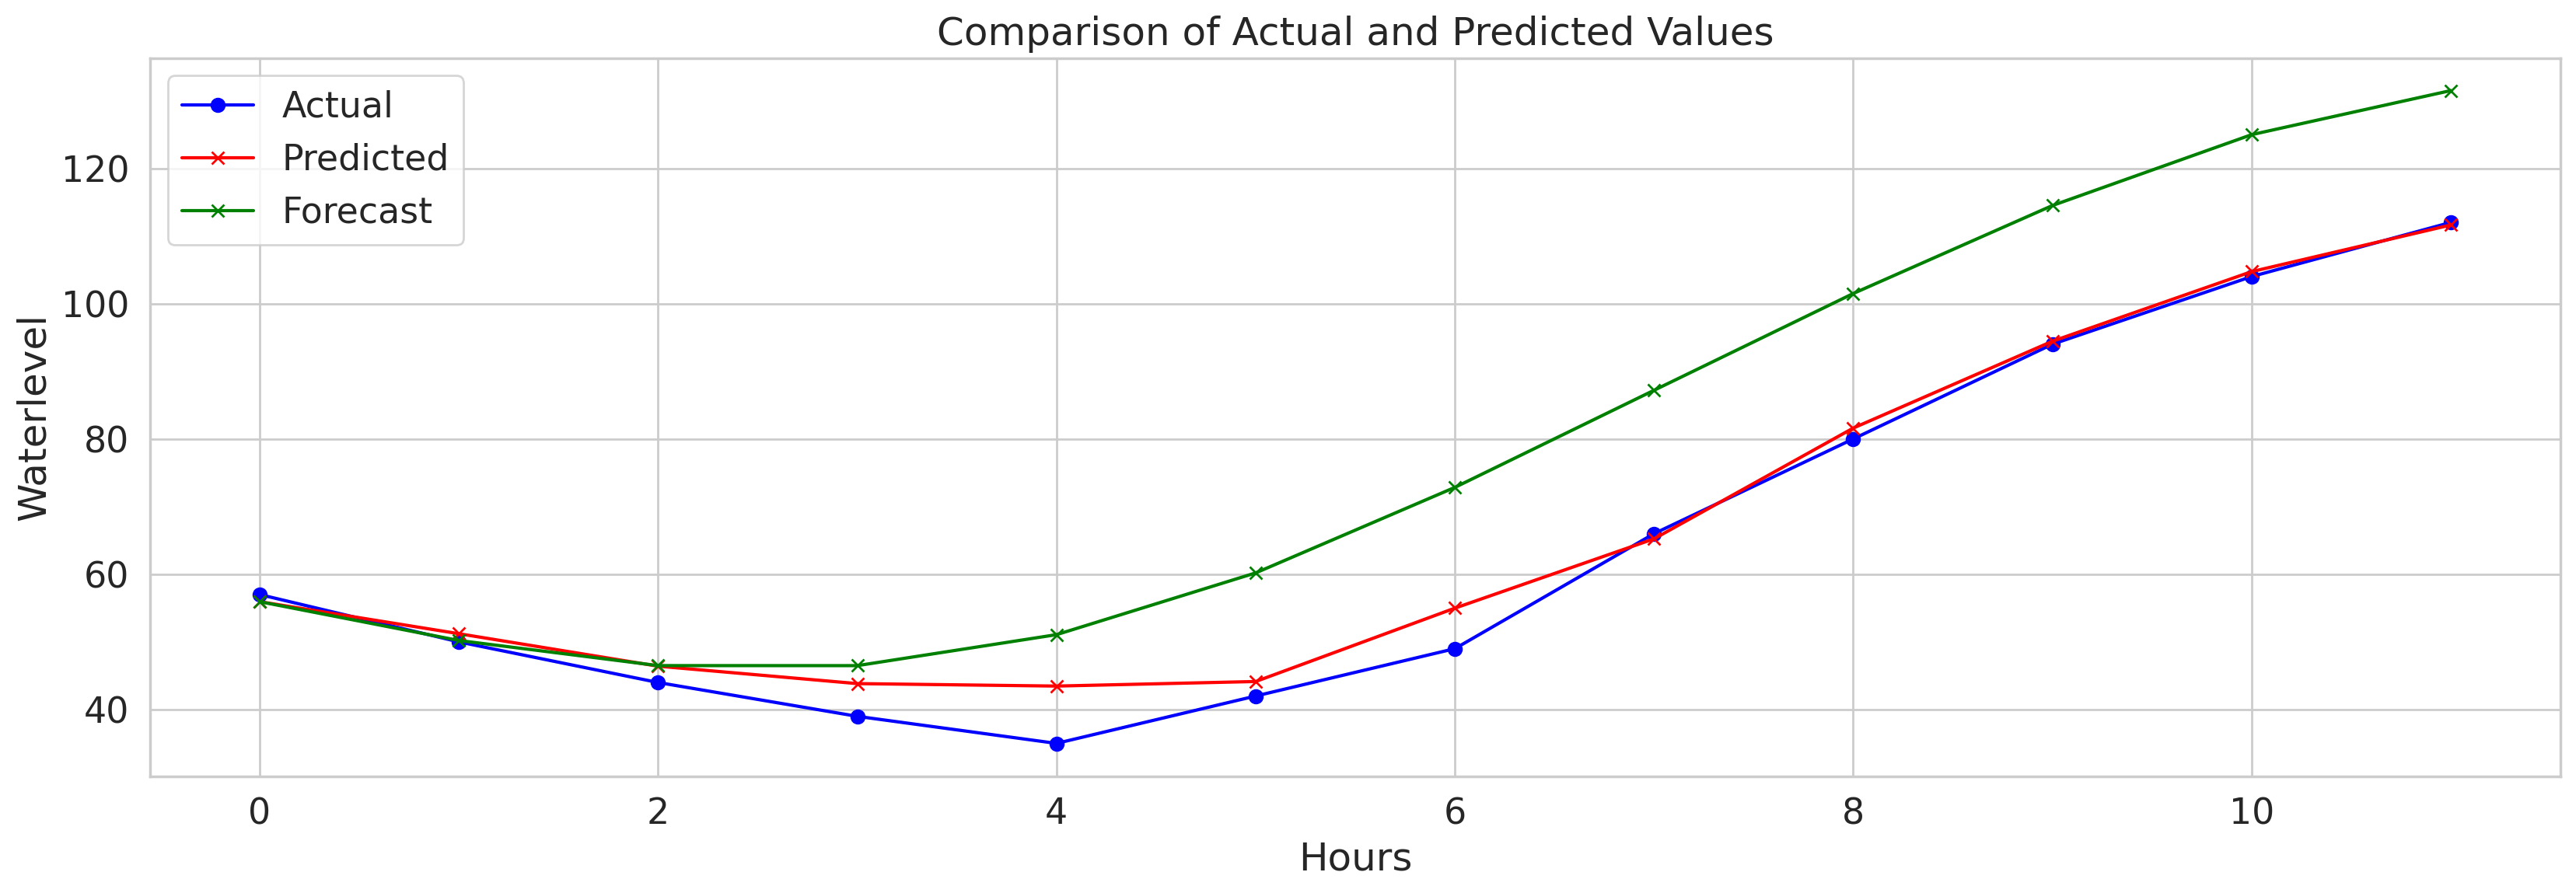

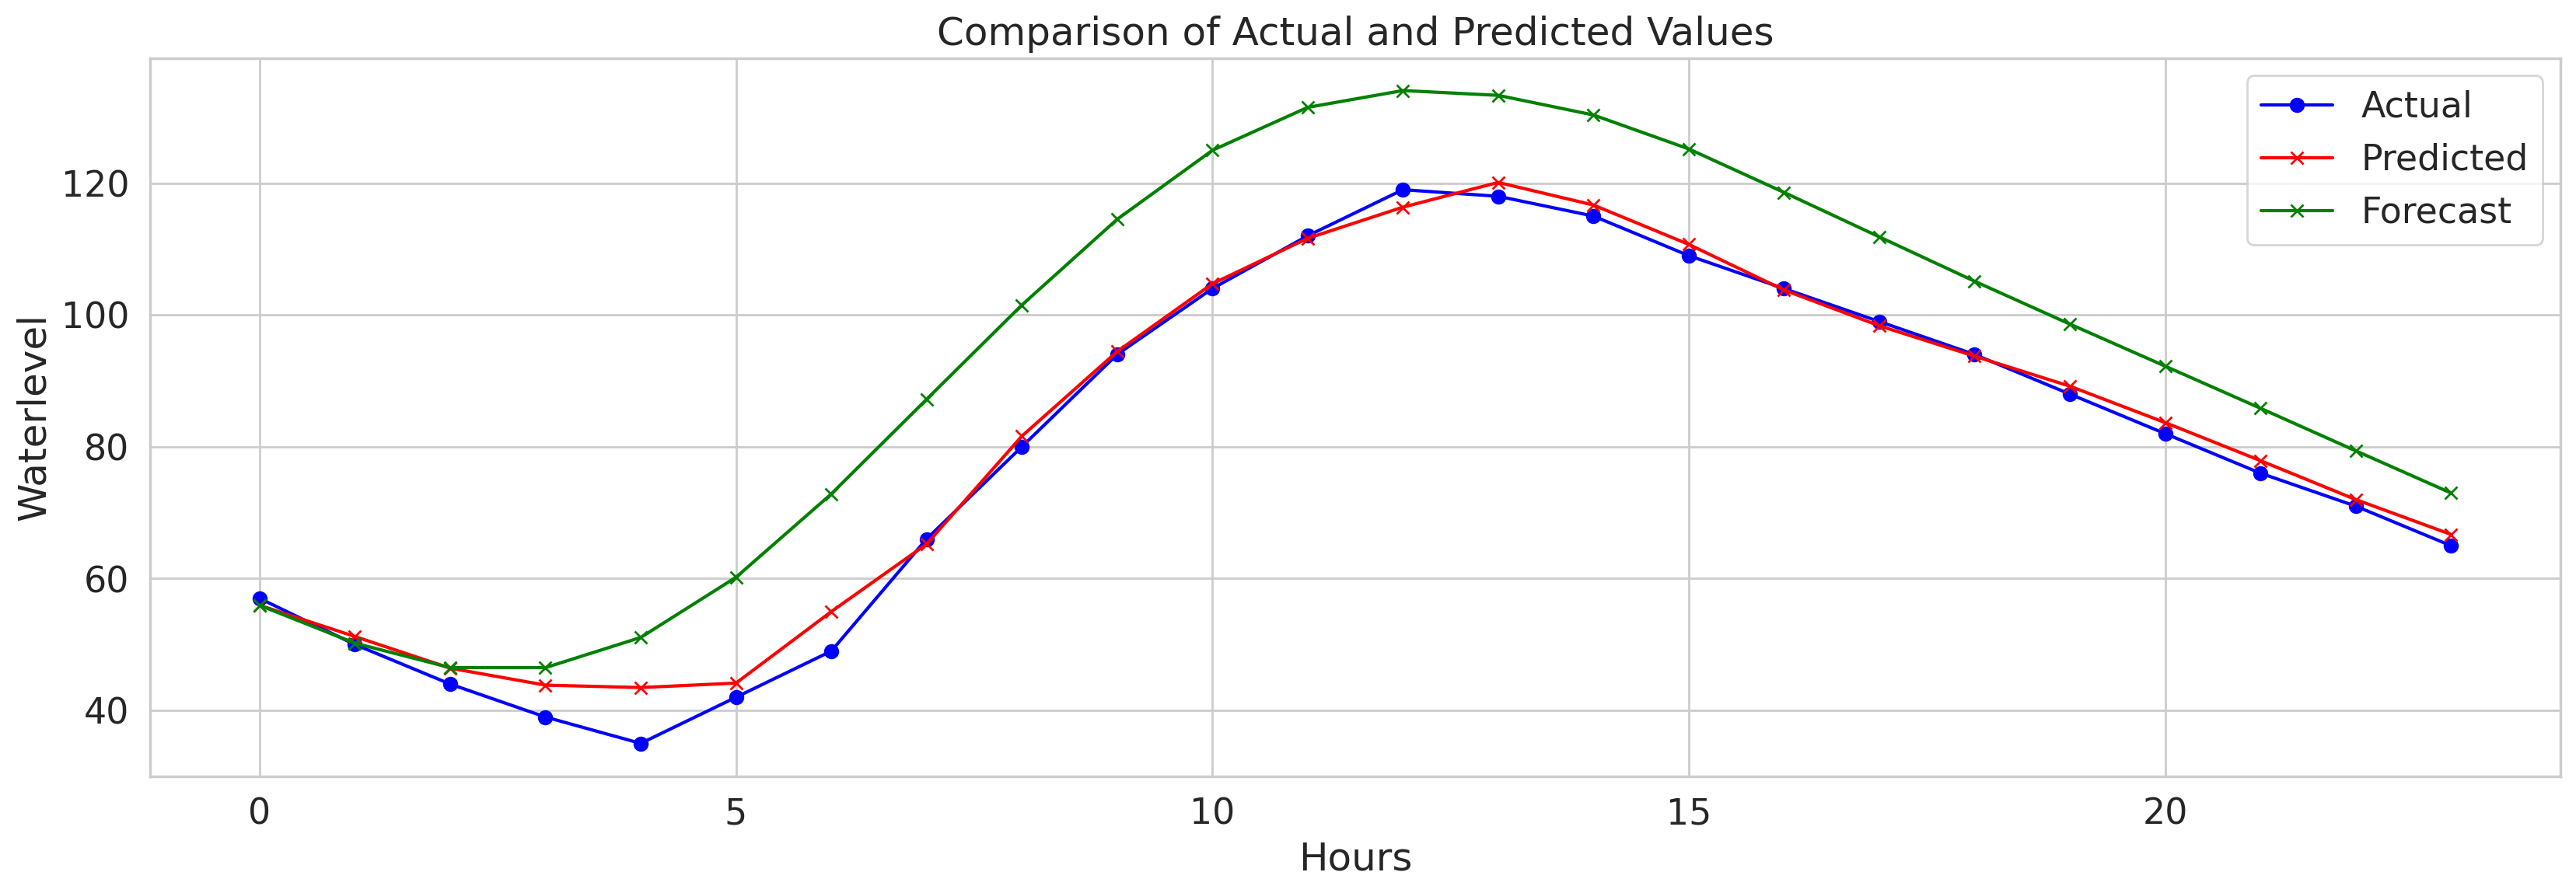

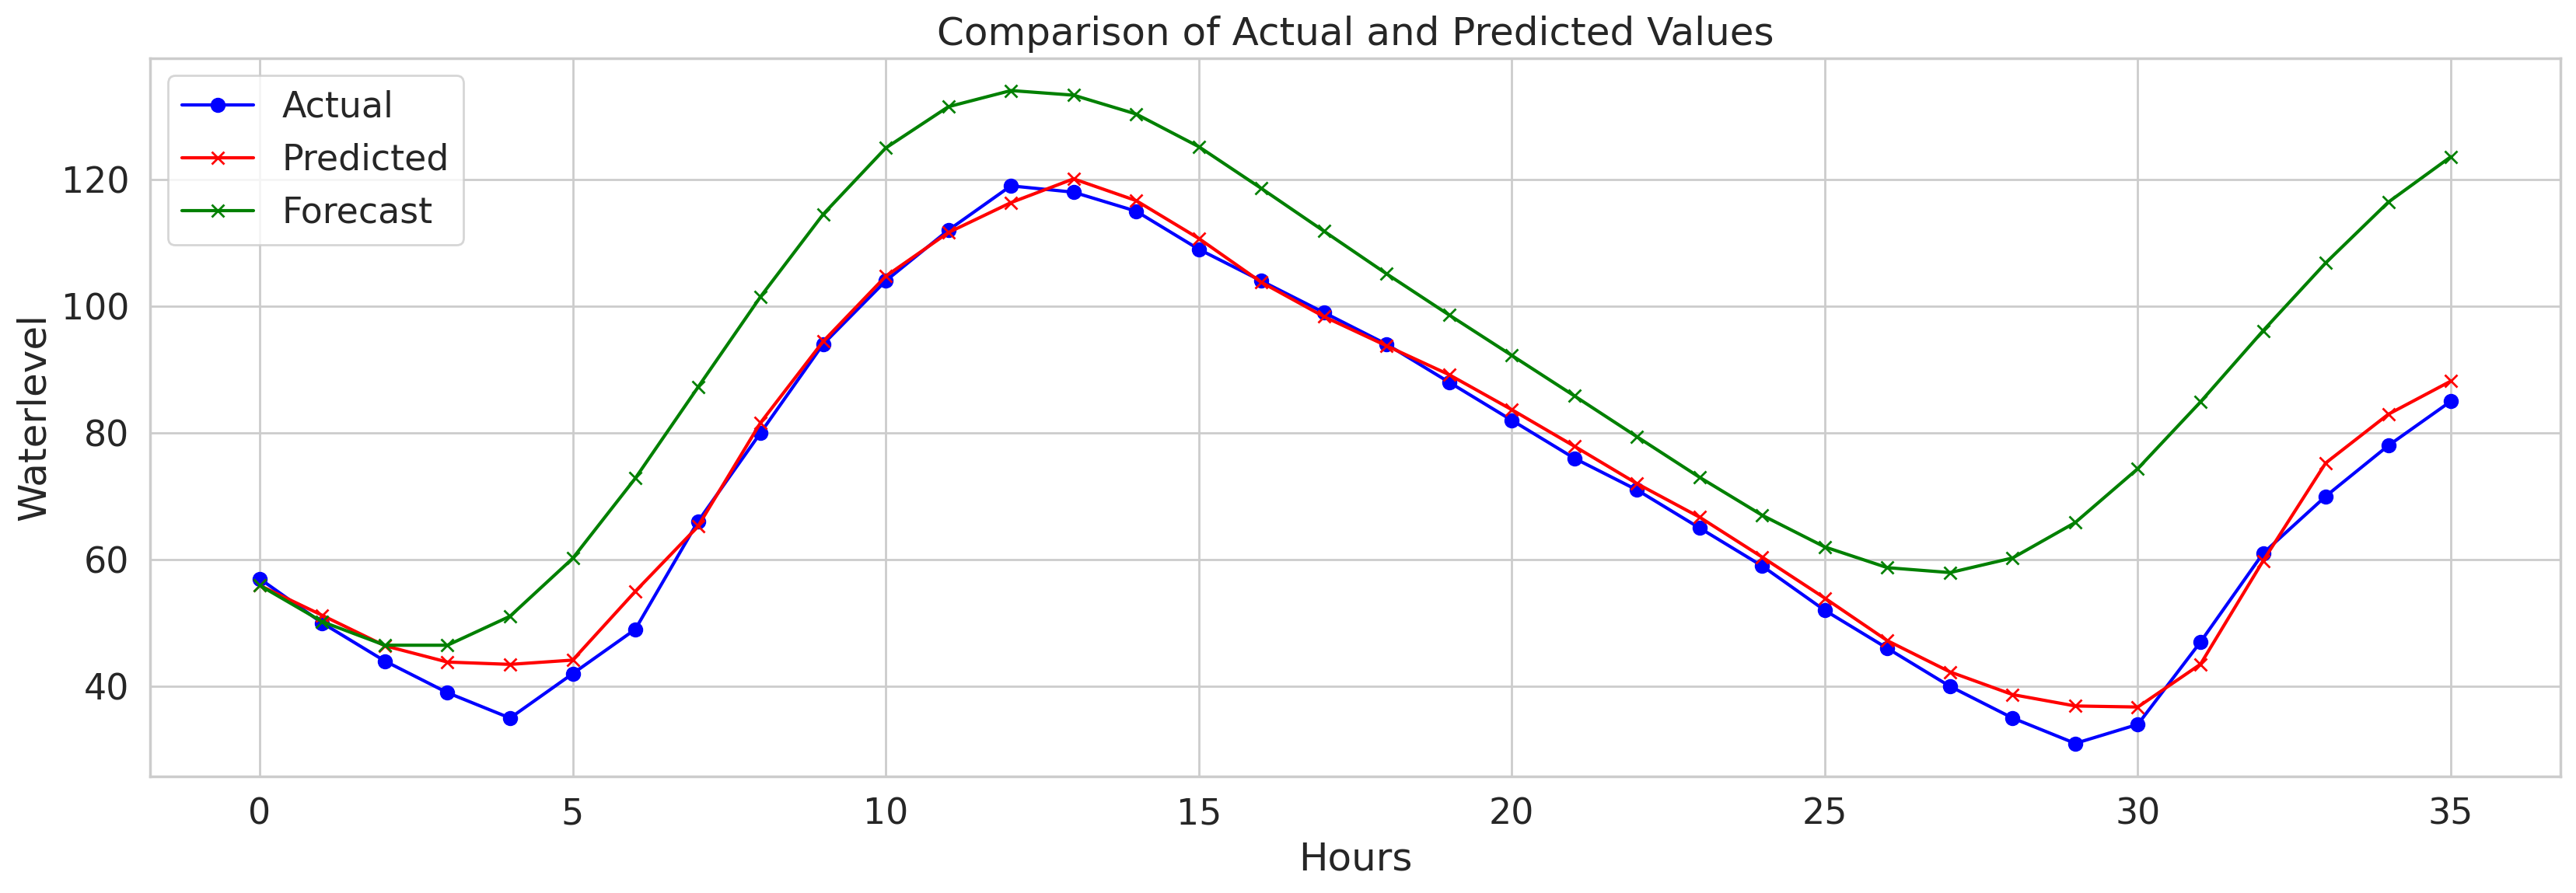

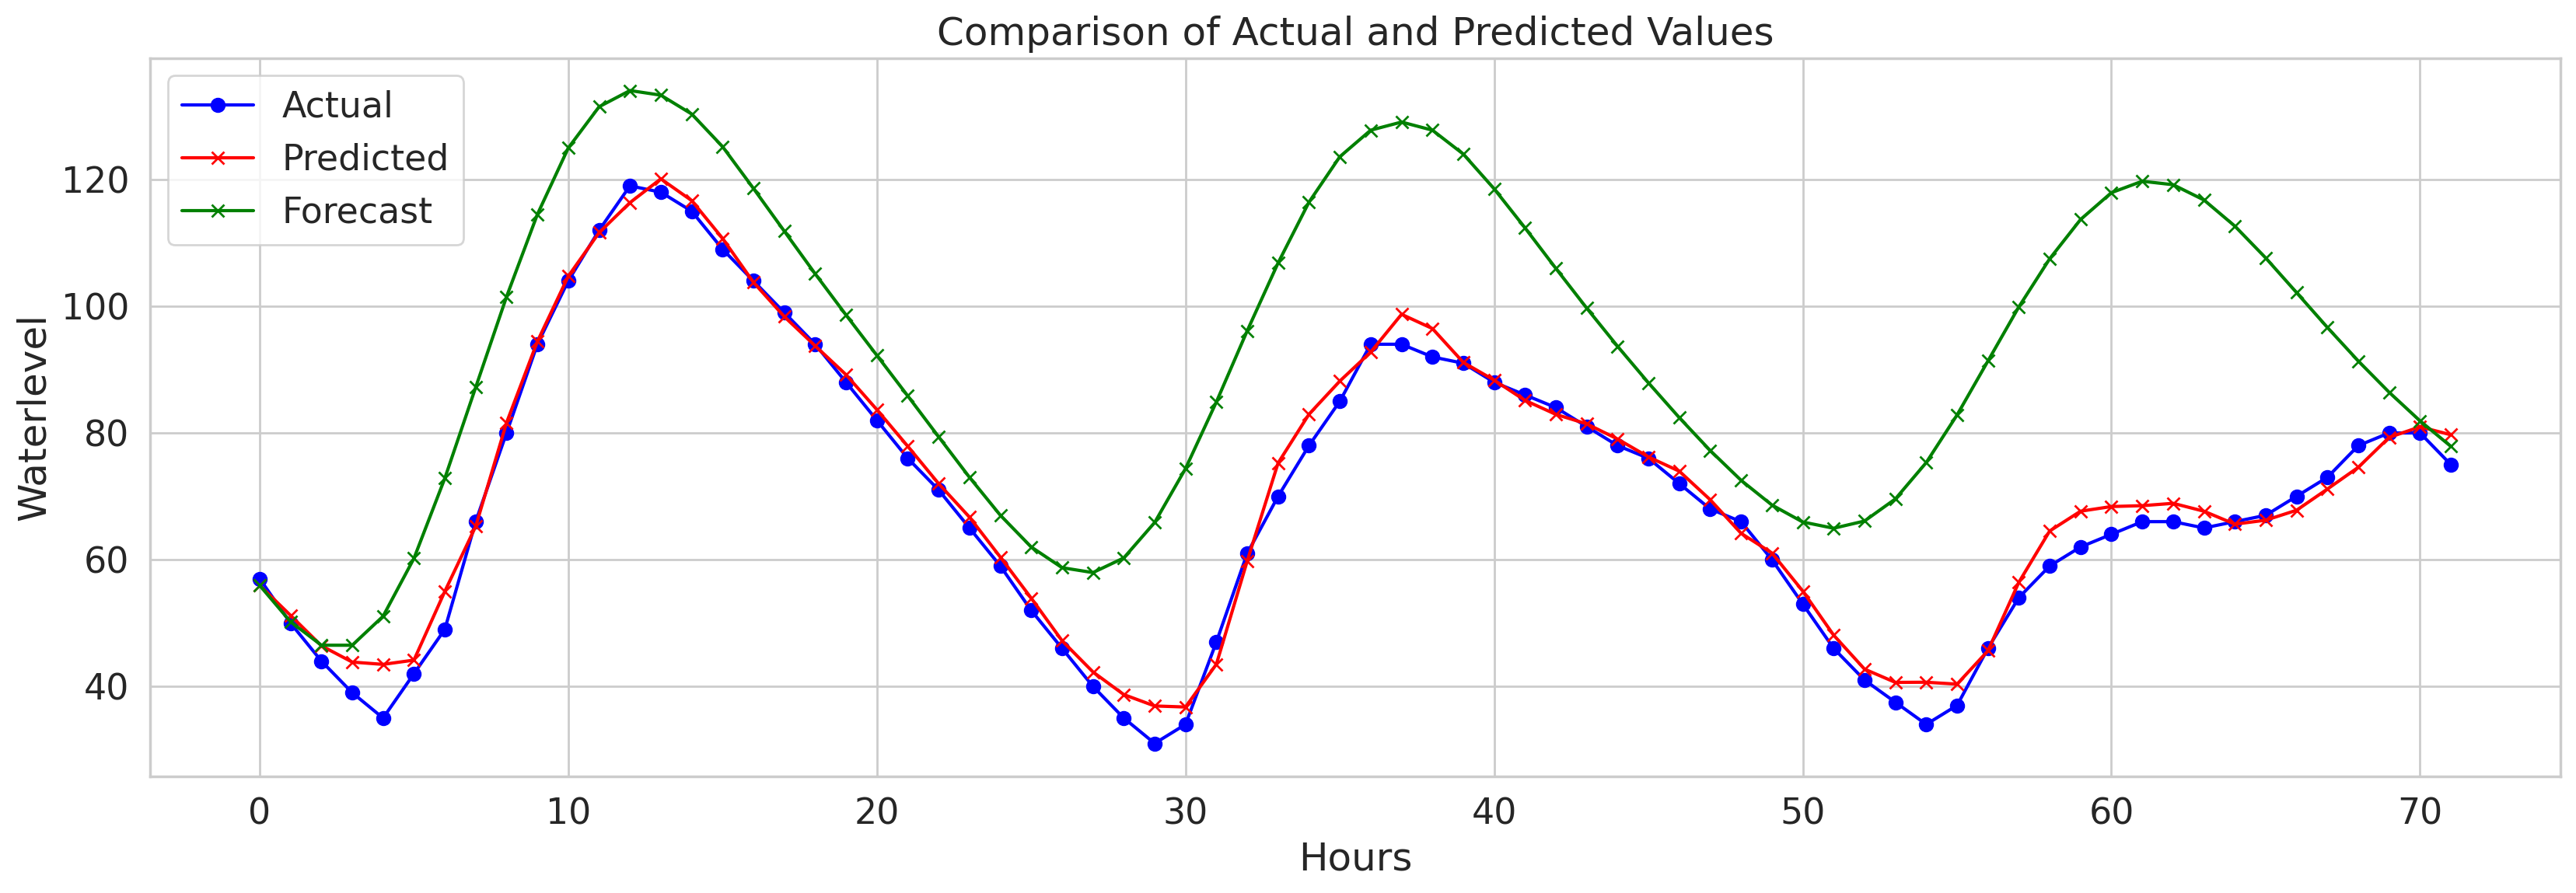

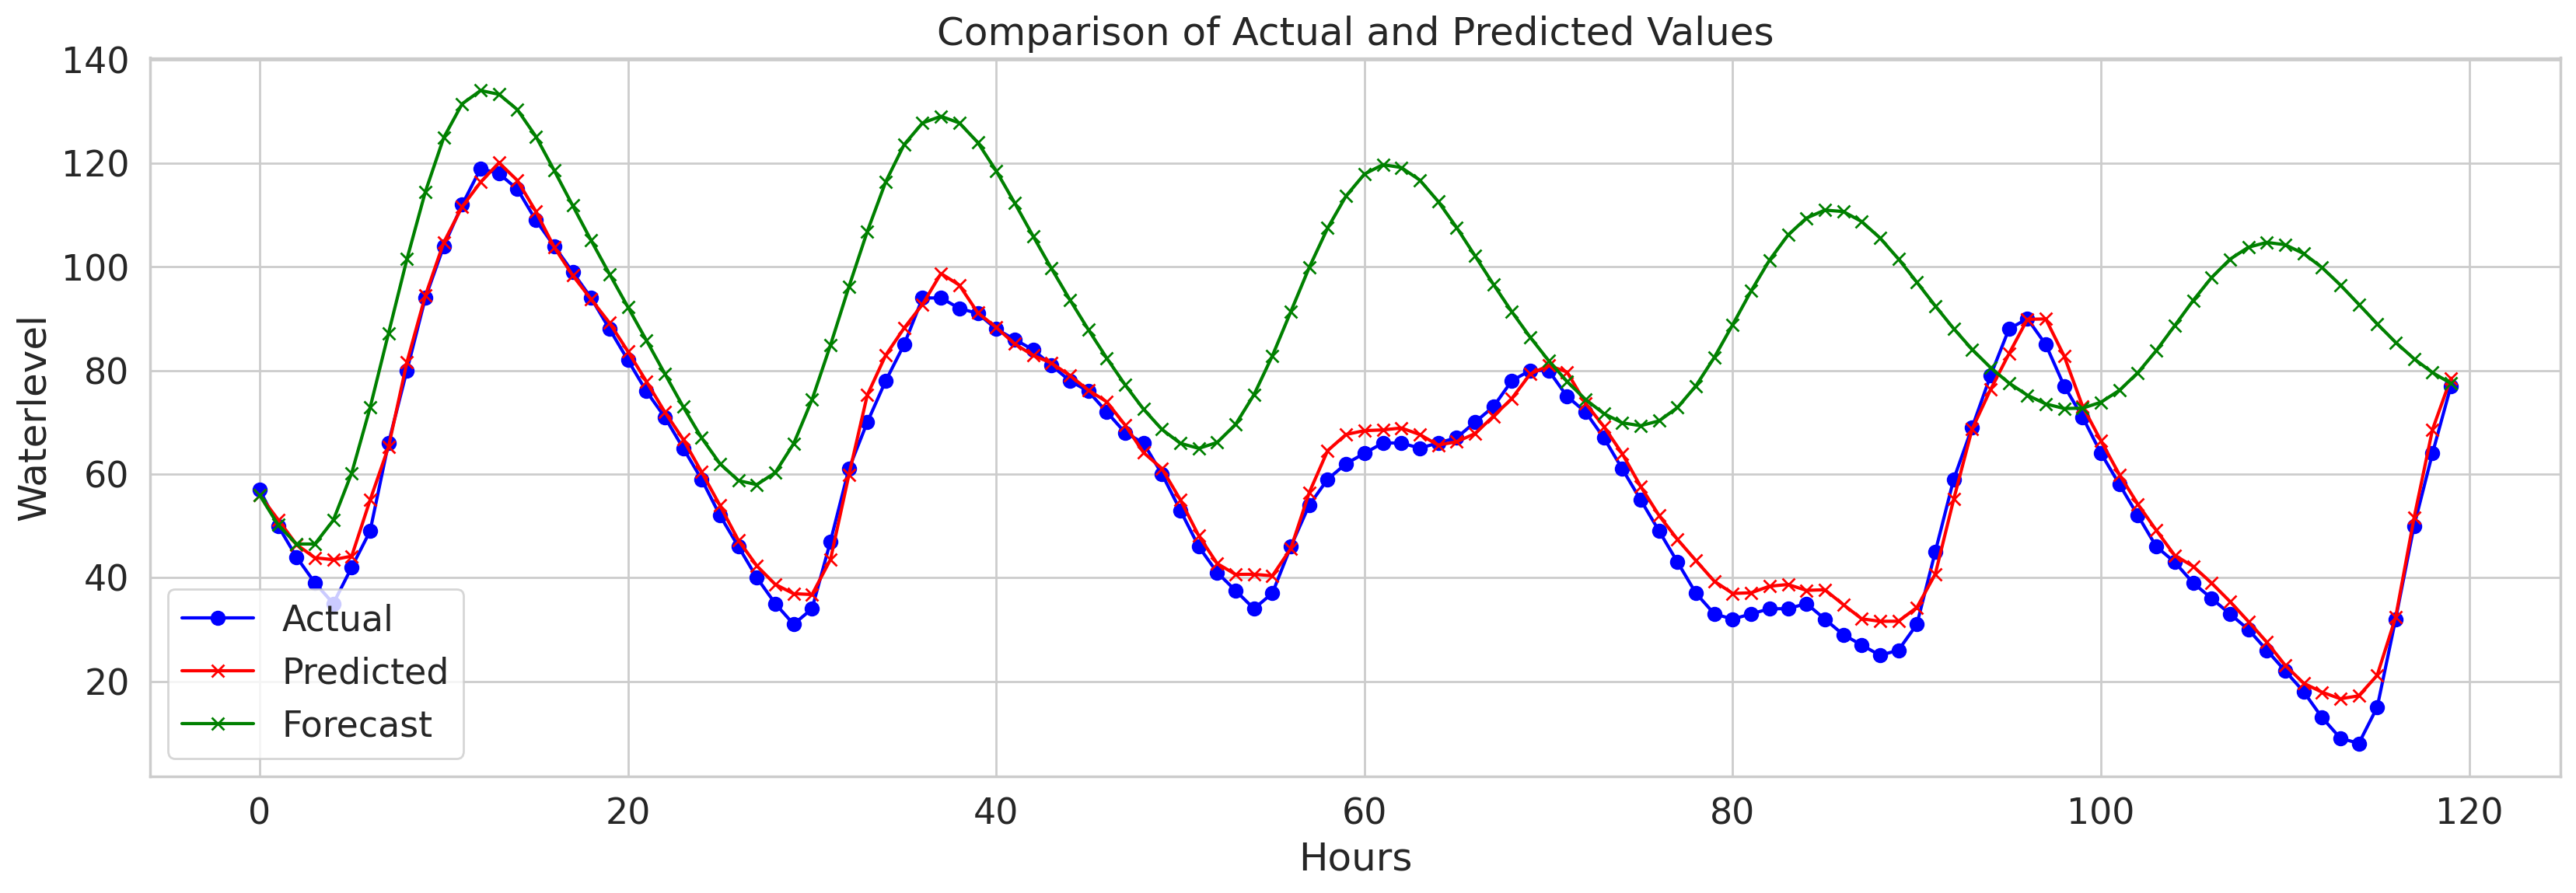

In [53]:
time_forecast = [3,  6, 12, 24, 36, 72, 120]
for hours in time_forecast:
    plt.figure(figsize=(20, 6))
    
    plt.plot(y_test_original[time : time + hours].flatten(), label='Actual', color='blue', marker='o')
    plt.plot(y_pred_original[: hours], label='Predicted', color='red', marker='x')
    plt.plot(y_fc_original[: hours].flatten(), label='Forecast', color='green', marker='x')
    plt.title('Comparison of Actual and Predicted Values')
    plt.xlabel('Hours')
    plt.ylabel('Waterlevel')
    plt.legend()

    plt.show()

In [54]:
time_forecast = [3,  6, 12, 24, 36, 72, 120]
for hours in time_forecast:
    metrics = calculate_metrics(y_test_original[:hours].flatten(), y_fc_original[:hours].flatten())
    for metric, value in metrics.items():
        print(f'Using model LSTM {hours} hours {metric}: {value}')
    print('\n')

Using model LSTM 3 hours MAE: 6.117002499600251
Using model LSTM 3 hours RMSE: 6.4107662550930025
Using model LSTM 3 hours MSE: 41.09792397743916
Using model LSTM 3 hours R: 0.9924174951001682
Using model LSTM 3 hours SIM: 0.702644261067977
Using model LSTM 3 hours FSD: 1.912172709879995
Using model LSTM 3 hours NSE: -0.2580997135950762


Using model LSTM 6 hours MAE: 9.518354178716736
Using model LSTM 6 hours RMSE: 11.821221980910067
Using model LSTM 6 hours MSE: 139.74128912195133
Using model LSTM 6 hours R: -0.07661145552926016
Using model LSTM 6 hours SIM: 0.7635936286402288
Using model LSTM 6 hours FSD: 1.9307155606035649
Using model LSTM 6 hours NSE: -0.45227667678702366


Using model LSTM 12 hours MAE: 18.215591534351304
Using model LSTM 12 hours RMSE: 21.007031940143087
Using model LSTM 12 hours MSE: 441.29539093419174
Using model LSTM 12 hours R: 0.8875862004494504
Using model LSTM 12 hours SIM: 0.8170644483023435
Using model LSTM 12 hours FSD: 1.9886798671731374
Using model L

In [55]:
from keras.models import load_model
pretrained_model = keras.models.load_model('Model_1.h5')

In [56]:
from keras.layers import Input
from keras.models import Model

# Extract layers from the pre-trained model except the last layer
pretrained_layers = pretrained_model.layers[:-1]

# Create a new model and add pre-trained layers
input_layer = Input(shape=(x_train.shape[1],1))
x = input_layer
for layer in pretrained_layers:
    x = layer(x)

# Add new LSTM layers
x = LSTM(50, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(50, return_sequences=False)(x)
x = Dropout(0.2)(x)
output_layer = Dense(1)(x)

# Compile the new model
transfer_model = Model(inputs=input_layer, outputs=output_layer)
transfer_model.compile(optimizer='adam', loss='mean_squared_error')

ValueError: Input 0 of layer "lstm_4" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 32)

In [ ]:
# Train the new model
history = transfer_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

## 